In [23]:
import pandas as pd 
import numpy as np  

import os

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import ModelCheckpoint
from keras.utils import to_categorical

In [2]:
data = pd.read_hdf("../initialSingleCellDf-channel-20220916-MW_018-001.h5", key="df")
MARKERS = data.columns
# ANTIGENS = ['V4', 'T4', 'Q4', 'A2', 'N4']  # Only focus on the strong markers. 
ANTIGENS = ['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']
TIMES = [4.0, 12.0, 24.0, 30.0, 36.0, 48.0, 60.0, 72.0]
TEST_PROPORTION = 0.25

# %%
# Filter the data to the strong antigens, first repliate, OT-1 cells, high concentration, and later. 
df = data.loc[(data.index.get_level_values('CellType') == 'OT-1') & 
                       (data.index.get_level_values('Replicate') == '1') &
                    #    (data.index.get_level_values('Time') >= 30.0) & # [4.0, 12.0, 24.0, 30.0, 36.0, 48.0, 60.0, 72.0]
                       (data.index.get_level_values('Peptide').isin(ANTIGENS))
                    ]

group_size = 10

def avg(group): 
    group['GroupNumber'] = np.array(range(len(group.index))) // group_size
    res = group.groupby('GroupNumber').mean()
    return res

averaged_df = df.groupby(['Peptide', 'Time']).apply(avg)

print(averaged_df)
averaged_df = pd.DataFrame(StandardScaler().fit_transform(averaged_df), columns=averaged_df.columns, index=averaged_df.index) 

Marker                    FSC-A  SSC-A   CD25   CD38  Granzyme B    CD2  \
Peptide Time GroupNumber                                                  
A2      30.0 0            528.6  224.0  391.9  274.5       381.9  226.0   
             1            594.3  226.5  432.5  265.6       357.6  141.9   
             2            563.8  236.4  456.7  280.9       370.8  220.3   
             3            441.2  207.2  393.5  269.1       334.6  225.2   
             4            427.1  250.0  387.8  271.4       332.0  215.0   
...                         ...    ...    ...    ...         ...    ...   
null    72.0 3423         294.0  132.1  299.4  302.8       292.8  182.0   
             3424         236.6  112.2  284.8  303.8       315.1  252.4   
             3425         344.5   99.0  323.5  299.4       320.9  277.7   
             3426         376.1  146.7  283.8  304.6       303.2  197.2   
             3427         383.0  138.5  279.5  431.5       273.5   93.0   

Marker                  

In [3]:
selected_columns = ['FSC-A', 'SSC-A', 'CD25', 'CD38', 'Granzyme B', 'CD2', 'CD27', 'CD45RA',
       'CD4', 'CD86', 'CXCR6', 'CD5', 'CD62L', 'OX40', 'PD-L1', 'TBet',
       'CD126', 'Proliferation', 'ICOS', 'IRF8', 'CD19', 'MHC-II', 'CD45',
       'CD44', 'CX3CR1', 'CD8a']

# Extract the selected columns into a new DataFrame
selected_df = averaged_df[selected_columns].reset_index(drop=True)
print(selected_df.columns)
selected_df

Index(['FSC-A', 'SSC-A', 'CD25', 'CD38', 'Granzyme B', 'CD2', 'CD27', 'CD45RA',
       'CD4', 'CD86', 'CXCR6', 'CD5', 'CD62L', 'OX40', 'PD-L1', 'TBet',
       'CD126', 'Proliferation', 'ICOS', 'IRF8', 'CD19', 'MHC-II', 'CD45',
       'CD44', 'CX3CR1', 'CD8a'],
      dtype='object', name='Marker')


Marker,FSC-A,SSC-A,CD25,CD38,Granzyme B,CD2,CD27,CD45RA,CD4,CD86,...,CD126,Proliferation,ICOS,IRF8,CD19,MHC-II,CD45,CD44,CX3CR1,CD8a
0,1.167869,-0.234837,0.230152,-0.595901,0.324301,-0.834129,0.944227,0.369626,-0.196731,-0.614911,...,0.389459,0.767001,-0.135462,1.289488,1.756529,-0.199983,1.051956,1.383556,0.878254,-1.029203
1,1.809092,-0.213064,0.645065,-1.279786,-0.105335,-1.714510,1.661472,0.930319,-1.405753,2.190861,...,0.888644,0.898636,0.195533,2.747975,-0.102149,-0.829382,0.636555,2.851188,1.625906,-0.341204
2,1.511416,-0.126843,0.892378,-0.104118,0.128047,-0.893798,1.664823,1.264927,-2.565226,1.023358,...,1.002095,0.676383,0.614082,2.918324,2.205880,-1.256564,0.493053,1.171928,1.674666,-0.269908
3,0.314857,-0.381151,0.246504,-1.010842,-0.511986,-0.842503,0.486732,0.025976,-0.464302,0.336039,...,0.071796,0.718353,-0.061788,1.940257,-0.020449,-0.680247,0.231225,1.209780,-0.001457,-1.022074
4,0.177243,-0.008398,0.188252,-0.834108,-0.557955,-0.949280,0.654312,-0.231762,-0.325561,0.882128,...,0.734350,1.210553,-0.040434,0.322905,0.258693,-0.111513,0.953770,1.288926,0.169203,-0.711939
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226959,-1.121795,-1.035210,-0.715154,1.578701,-1.251029,-1.294733,-0.915918,0.568582,0.041109,1.663602,...,-0.931112,0.526624,-0.170697,-0.347003,1.647595,0.024983,-0.438451,1.132355,-1.886840,-1.186053
226960,-1.682011,-1.208523,-0.864359,1.655542,-0.856755,-0.557767,-0.837155,-0.801499,-0.008441,-0.661988,...,-0.999182,0.870973,-1.195713,-1.566237,-0.360866,0.270171,0.467878,-1.095762,-0.692222,-0.019484
226961,-0.628922,-1.323484,-0.468864,1.317442,-0.754208,-0.292919,-0.232189,-0.408109,0.764541,0.543176,...,-0.599835,0.508501,-0.276401,-0.377628,-0.170232,0.027511,0.047442,0.043245,-1.116840,-0.198613
226962,-0.320510,-0.908056,-0.874579,1.717015,-1.067152,-1.135615,-0.485236,0.161627,0.417690,0.853882,...,-0.014427,0.516132,-1.245896,0.133417,1.688446,0.904625,-0.332713,0.951697,-0.905547,-0.782343


In [4]:
antigen = list(averaged_df.index.get_level_values('Peptide'))
time = list(averaged_df.index.get_level_values('Time'))

In [5]:
X = np.array(averaged_df.values)
print(X.shape)
print(X)
y = np.array(list(map(lambda x: ANTIGENS.index(x), antigen)))
print("y: ", y)
y = to_categorical(y)
print("yshape", y.shape)
print(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_PROPORTION, random_state=42)

print(X_train.shape)
print(y_train.shape)

(226964, 26)
[[ 1.16786875 -0.23483668  0.23015238 ...  1.38355598  0.87825379
  -1.02920304]
 [ 1.80909163 -0.21306374  0.64506536 ...  2.85118822  1.62590599
  -0.34120369]
 [ 1.51141586 -0.12684287  0.89237802 ...  1.17192788  1.67466592
  -0.26990843]
 ...
 [-0.6289217  -1.32348395 -0.46886357 ...  0.04324471 -1.11683986
  -0.19861316]
 [-0.32051008 -0.90805615 -0.87457896 ...  0.95169702 -0.90554685
  -0.78234317]
 [-0.25316704 -0.97947141 -0.91852295 ...  3.32089936  1.01437525
  -1.88831104]]
y:  [6 6 6 ... 0 0 0]
yshape (226964, 8)
[[0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]]
(170223, 26)
(170223, 8)


In [10]:
# autoencoder = Sequential([
#     layers.InputLayer(input_shape=(26,)),
#     layers.Dense(13, activation='elu'),
#     layers.Dense(5, activation='relu'),
#     layers.Dense(2, activation='linear', name="Bottleneck"), # The bottleneck. 
#     layers.Dense(5, activation='relu'),
#     layers.Dense(13, activation='sigmoid'),
#     layers.Dense(26, activation='tanh'),
# ])
autoencoder = Sequential([
    layers.InputLayer(input_shape=(26,)),
    layers.Dense(13, activation='elu'),
    layers.Dense(7, activation='relu'),
    layers.Dense(3, activation='linear', name="Bottleneck"), # The bottleneck. 
    layers.Dense(7, activation='elu'),
    layers.Dense(13, activation='relu'),
    layers.Dense(26, activation='linear'),
])

In [11]:
autoencoder.compile(optimizer='adagrad', loss=losses.MeanSquaredError(), metrics=['mse'])


In [15]:
CHECKPOINT_PATH = "training/train_avg/cp-{epoch:04d}.ckpt"
checkpoint_dir = os.path.dirname(CHECKPOINT_PATH)

BATCH_SIZE = 1024
STEPS_PER_EPOCH = X_train.shape[0] / BATCH_SIZE
SAVE_PERIOD = 10


training_callback = ModelCheckpoint(filepath=CHECKPOINT_PATH,
                                    save_weights_only=True,
                                    verbose=1, 
                                    save_freq=int(SAVE_PERIOD * STEPS_PER_EPOCH)
                                )

# autoencoder.save_weights(CHECKPOINT_PATH.format(epoch=0))

tf.random.set_seed(42)

hist = autoencoder.fit(X_train, X_train,
                epochs=1000,
                shuffle=True,
                validation_data=(X_test, X_test),
                callbacks=[training_callback],
                batch_size=BATCH_SIZE,
                verbose=0)


Epoch 10: saving model to training/train_avg/cp-0010.ckpt

Epoch 20: saving model to training/train_avg/cp-0020.ckpt

Epoch 30: saving model to training/train_avg/cp-0030.ckpt

Epoch 40: saving model to training/train_avg/cp-0040.ckpt

Epoch 50: saving model to training/train_avg/cp-0050.ckpt

Epoch 60: saving model to training/train_avg/cp-0060.ckpt

Epoch 70: saving model to training/train_avg/cp-0070.ckpt

Epoch 80: saving model to training/train_avg/cp-0080.ckpt

Epoch 90: saving model to training/train_avg/cp-0090.ckpt

Epoch 100: saving model to training/train_avg/cp-0100.ckpt

Epoch 110: saving model to training/train_avg/cp-0110.ckpt

Epoch 120: saving model to training/train_avg/cp-0120.ckpt

Epoch 130: saving model to training/train_avg/cp-0130.ckpt

Epoch 140: saving model to training/train_avg/cp-0140.ckpt

Epoch 150: saving model to training/train_avg/cp-0150.ckpt

Epoch 160: saving model to training/train_avg/cp-0160.ckpt

Epoch 170: saving model to training/train_avg/cp

KeyError: 'val_categorical_accuracy'

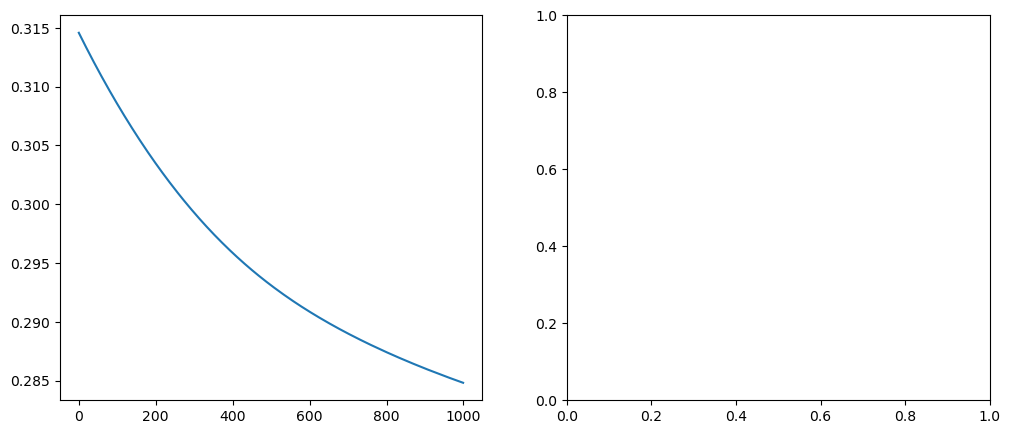

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot the accuracy on the first subplot
ax1.plot(hist.history['mse'], label='Accuracy')
ax1.plot(hist.history['val_categorical_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Plot the loss on the second subplot
ax2.plot(hist.history['loss'], label='Loss')
ax2.plot(hist.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

# Adjust the spacing between subplots
plt.tight_layout()

In [17]:
autoencoder.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 13)                351       
                                                                 
 dense_6 (Dense)             (None, 7)                 98        
                                                                 
 Bottleneck (Dense)          (None, 3)                 24        
                                                                 
 dense_7 (Dense)             (None, 7)                 28        
                                                                 
 dense_8 (Dense)             (None, 13)                104       
                                                                 
 dense_9 (Dense)             (None, 26)                364       
                                                                 
Total params: 969 (3.79 KB)
Trainable params: 969 (3.7

In [19]:
train_time, test_time = train_test_split(time, test_size=TEST_PROPORTION, random_state=42)
train_antigen, test_antigen = train_test_split(antigen, test_size=TEST_PROPORTION, random_state=42)

In [22]:
extractor = Model(inputs=autoencoder.inputs,
                        outputs=autoencoder.get_layer("Bottleneck").output)
embedding = np.array( extractor(X_test) )

print(embedding.shape)

import plotly.express as px

# Assuming you have X_test, embedding, test_antigen, test_time, and ANTIGENS defined

# Create a DataFrame with the embedding data
df = pd.DataFrame(embedding, columns=['Dimension 1', 'Dimension 2', 'Dimension 3'])
df['Antigen'] = pd.Categorical(test_antigen)

# Create an interactive 3D scatter plot
fig = px.scatter_3d(
    df,
    x='Dimension 1',
    y='Dimension 2',
    z='Dimension 3',
    color='Antigen',
    color_discrete_sequence=px.colors.qualitative.Set1,  # Define a color palette
    title="Autoencoder 3D Embedding Averaged Data (Validation Set)"
)

# Customize the appearance and interactivity if needed
fig.update_traces(marker=dict(size=4))
fig.update_layout(legend_title="Antigens")

# Show the plot
fig.show()

#data shader -> overlap
#accuracy per category (predicting better E1 vs others)

(56741, 3)


In [ ]:
MARKERS = ['SSC-A','CD25','Granzyme B','CD2','CD27','CD5','CD126','ICOS','IRF8','CD8a']

fig, axs = plt.subplots(2, 5, figsize=(15,5))

axs = axs.flatten()

vmin = -2 * np.std(averaged_df.values)
vmax = 2 * np.std(averaged_df.values)

for i, marker in enumerate(MARKERS):
    train_marker, test_marker = train_test_split(averaged_df[marker], test_size=TEST_PROPORTION, random_state=42)

    sc = axs[i].scatter(
        x=embedding[:,0], 
        y=embedding[:,1], 
        c=test_marker, 
        cmap='Blues', 
        s=1, 
        vmin=vmin,
        vmax=vmax
    )

    axs[i].set_title(marker)

plt.tight_layout()

# cax = fig.add_axes([0.92, 0.1, 0.02, 0.8])
plt.colorbar(sc, ax=axs.ravel().tolist())

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = np.argmax( autoencoder(X_test), axis=1 )
y_true = np.argmax(y_test, axis=1) 

cm = confusion_matrix(y_true, y_pred)

cm

In [ ]:
# Create a figure and axes
fig, ax = plt.subplots()

# Create the heatmap using seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)

# Set labels for the x and y axes
ax.set_xticklabels(ANTIGENS)
ax.set_yticklabels(ANTIGENS)